In [2]:
import warnings
warnings.filterwarnings(action="ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 0 - 3.5 lpa
# 1 - 4.5 lpa
# 2 - 5.5 lpa
# 3 - 6.5 lpa
# 4 - 7.5 lpa
# 5 - 8.5 lpa
# 6 - 9.5 lpa
# 7 - 10.5 lpa
# What is the intercept value and what is the slope value?
# -- interecept = 3.5
# -- Slope      = 1.0

In [33]:
salary_details = {"Experiance":[0,1,2,3,4,5,6,7],
                 "Salary": [3.5,4.5,5.5,15,7.5,8.5,9.5,10.5]}
salary_details

{'Experiance': [0, 1, 2, 3, 4, 5, 6, 7],
 'Salary': [3.5, 4.5, 5.5, 15, 7.5, 8.5, 9.5, 10.5]}

In [34]:
# salary_details = {"Experiance":[0,1,2,3,4,5,6,7],
#                  "Salary": [2.5,8.5,3.6,15.8,2.5,3.5,9.5,10.5]}
# salary_details

In [35]:
salary_details = pd.DataFrame(salary_details)
salary_details

,Experiance,Salary
0,0,3.5
1,1,4.5
2,2,5.5
3,3,15.0
4,4,7.5
5,5,8.5
6,6,9.5
7,7,10.5


In [36]:
# Linear regression - it says if there is some good positive or negative correlation between two
#                     variables, i can predict one variable using another variable.
# y - Dependent variable or response variable, target variable  (Example - Salary) (It should be contineous in regression)
# x - Independent variable or explanatory variable (Example - Experiane) (It can be both contineous and Categorical)

In [37]:
# Simple Linear regression - If there is only one independent variable(X), then we can that as SLR.
# Multiple Linear Regression - if there are more than two independent variables(X_1,X_2,....X_n), we 
#                              call it as MLR.

            Experiance    Salary
Experiance    1.000000  0.592294
Salary        0.592294  1.000000


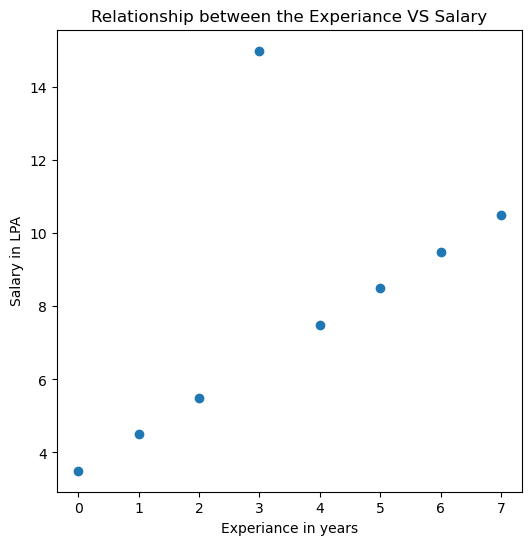

In [39]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(6,6))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.title("Relationship between the Experiance VS Salary")
print(salary_details.corr())
plt.show()

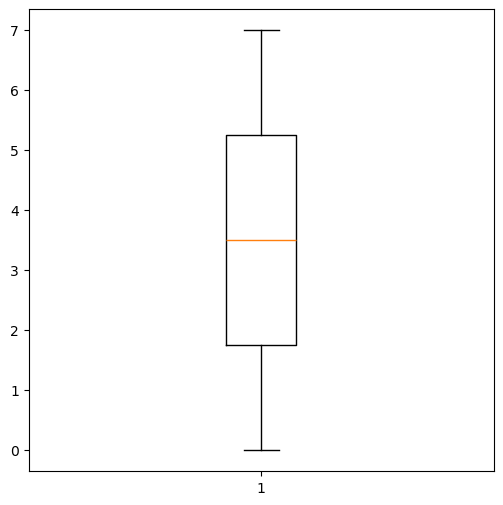

In [40]:
# Checking the distribution of the Experiance for detecting the outliers
plt.figure(figsize=(6,6))
plt.boxplot(x = salary_details["Experiance"])
plt.show()

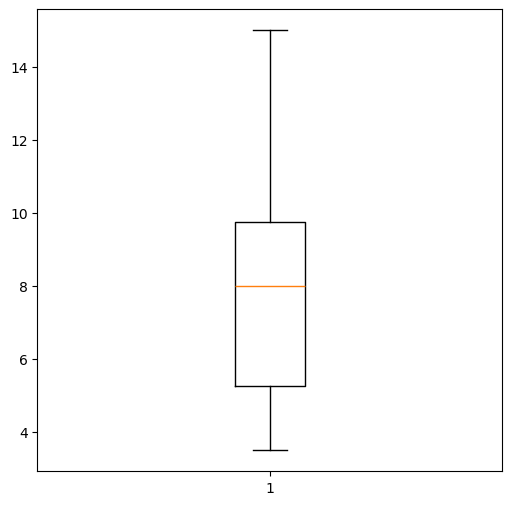

In [41]:
# Checking the distribution of the Salary for detecting the outliers
plt.figure(figsize=(6,6))
plt.boxplot(x = salary_details["Salary"])
plt.show()

In [42]:
import sklearn as sk

In [44]:
X = salary_details[["Experiance"]]
X

,Experiance
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


In [45]:
y = salary_details["Salary"]
y

0     3.5
1     4.5
2     5.5
3    15.0
4     7.5
5     8.5
6     9.5
7    10.5
Name: Salary, dtype: float64

In [46]:
model = sk.linear_model.LinearRegression()
model.fit(X,y)

LinearRegression()

In [47]:
# Predict the salary of the person who is having 10 years of experiance:
salary_details

,Experiance,Salary
0,0,3.5
1,1,4.5
2,2,5.5
3,3,15.0
4,4,7.5
5,5,8.5
6,6,9.5
7,7,10.5


In [48]:
model.predict(np.array([[10]]))  # Last Prediction 13.5

array([13.9047619])

In [49]:
model.intercept_     # Intercept of the line

4.916666666666666

In [50]:
model.coef_          # Slope of the line

array([0.89880952])

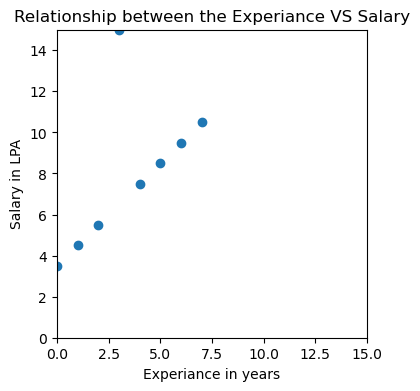

In [51]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(4,4))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.xlim(0,15)
plt.ylim(0,15)
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.title("Relationship between the Experiance VS Salary")
plt.show()

In [52]:
salary_details.corr()

,Experiance,Salary
Experiance,1.000000,0.592294
Salary,0.592294,1.000000


In [53]:
r = 0.592294

In [54]:
# Accuracy of the model
R_squared = r**2
R_squared

0.350812182436

In [55]:
model.predict(salary_details[["Experiance"]])

array([ 4.91666667,  5.81547619,  6.71428571,  7.61309524,  8.51190476,
        9.41071429, 10.30952381, 11.20833333])

In [56]:
pd.Series(model.predict(salary_details[["Experiance"]]))

0     4.916667
1     5.815476
2     6.714286
3     7.613095
4     8.511905
5     9.410714
6    10.309524
7    11.208333
dtype: float64

In [57]:
salary_details["Predicted_salaries"] = pd.Series(model.predict(salary_details[["Experiance"]]))

In [58]:
salary_details

,Experiance,Salary,Predicted_salaries
0,0,3.5,4.916667
1,1,4.5,5.815476
2,2,5.5,6.714286
3,3,15.0,7.613095
4,4,7.5,8.511905
5,5,8.5,9.410714
6,6,9.5,10.309524
7,7,10.5,11.208333


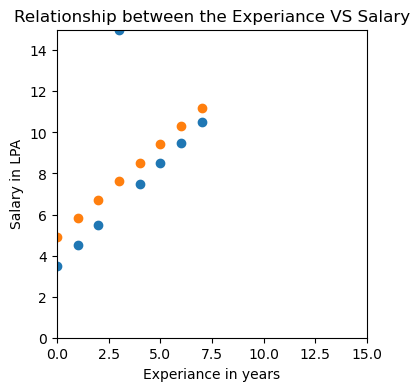

In [59]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(4,4))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.scatter(x = salary_details["Experiance"], y= salary_details["Predicted_salaries"])
plt.xlim(0,15)
plt.ylim(0,15)
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.title("Relationship between the Experiance VS Salary")
plt.show()

In [30]:
Error = salary_details["Salary"] - salary_details["Predicted_salaries"]
salary_details["Error"] = Error
salary_details

,Experiance,Salary,Predicted_salaries,Error
0,0,3.5,3.5,1.776357e-15
1,1,4.5,4.5,1.776357e-15
2,2,5.5,5.5,8.881784e-16
3,3,6.5,6.5,0.000000e+00
4,4,7.5,7.5,0.000000e+00
5,5,8.5,8.5,0.000000e+00
6,6,9.5,9.5,0.000000e+00
7,7,10.5,10.5,-1.776357e-15
